<a href="https://colab.research.google.com/github/dhanusharer/DL-practise/blob/main/keras05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# English → French Neural Machine Translator

A sequence-to-sequence model with **Bahdanau Attention** for English-to-French translation.

**Architecture overview:**
- Word-level tokenization (not character-level)
- Bidirectional LSTM encoder
- LSTM decoder with Bahdanau (additive) attention
- Beam search at inference for higher quality output
- Teacher forcing during training

**Dataset:** `english_french.csv` — ~229K English/French sentence pairs (Tatoeba)

**Why word-level?** Character-level models struggle with rare words and take far longer to converge. Word-level tokenization with a capped vocabulary gives a much better accuracy/cost tradeoff for a language pair as well-resourced as English–French.

## 1. Imports and Configuration

In [1]:
import re
import json
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense,
    Bidirectional, AdditiveAttention, Concatenate, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Hyperparameters
DATA_PATH      = 'english_french.csv'
NUM_SAMPLES    = 50000      # use 50K pairs for solid coverage
VOCAB_SIZE_EN  = 8000       # top N English words
VOCAB_SIZE_FR  = 12000      # French has more surface forms
EMBED_DIM      = 256
LATENT_DIM     = 512        # LSTM hidden units
DROPOUT_RATE   = 0.3
BATCH_SIZE     = 128
EPOCHS         = 50         # early stopping will kick in before this
BEAM_WIDTH     = 5

START_TOKEN = '<start>'
END_TOKEN   = '<end>'
OOV_TOKEN   = '<unk>'

## 2. Data Loading and Preprocessing

In [3]:
def unicode_to_ascii(text: str) -> str:
    """Normalize unicode characters to ASCII where possible."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )


def clean_english(text: str) -> str:
    text = text.lower().strip()
    text = unicode_to_ascii(text)
    text = re.sub(r"([?.!,'])", r' \1 ', text)
    text = re.sub(r'[^a-z?.!,\' ]+', ' ', text)
    text = re.sub(r' +', ' ', text)
    return text.strip()


def clean_french(text: str) -> str:
    """Keep accented characters — they matter in French."""
    text = text.lower().strip()
    text = re.sub(r"([?.!,;'\u00e0-\u00ff])", r' \1 ', text)
    text = re.sub(r'[^a-z\u00e0-\u00ff?.!,;\' ]+', ' ', text)
    text = re.sub(r' +', ' ', text)
    return f"{START_TOKEN} {text.strip()} {END_TOKEN}"


def load_data(path: str, num_samples: int):
    df = pd.read_csv(path, on_bad_lines='skip')
    df.columns = ['english', 'french']
    df = df.dropna().drop_duplicates(subset='english')
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df = df.head(num_samples)

    df['english'] = df['english'].astype(str).apply(clean_english)
    df['french']  = df['french'].astype(str).apply(clean_french)

    # Remove rows where either side is empty after cleaning
    df = df[(df['english'].str.len() > 0) & (df['french'].str.len() > 10)]
    return df['english'].tolist(), df['french'].tolist()


english_sentences, french_sentences = load_data(DATA_PATH, NUM_SAMPLES)

print(f"Loaded {len(english_sentences)} sentence pairs")
print("\nSample pairs:")
for en, fr in zip(english_sentences[:5], french_sentences[:5]):
    print(f"  EN: {en}")
    print(f"  FR: {fr}")
    print()

Loaded 50000 sentence pairs

Sample pairs:
  EN: school is boring .
  FR: <start> l ' é cole , c ' est ennuyeux ! <end>

  EN: hurry , and you will catch the train .
  FR: <start> d é p ê che toi et tu auras ton train . <end>

  EN: i live about three hours from boston .
  FR: <start> j ' habite à environ trois heures de boston . <end>

  EN: the family had a hard time after the war .
  FR: <start> la famille a connu des heures difficiles apr è s la guerre . <end>

  EN: where are your keys ?
  FR: <start> o ù sont tes cl é s ? <end>



## 3. Tokenization

In [4]:
# English tokenizer
en_tokenizer = Tokenizer(num_words=VOCAB_SIZE_EN, oov_token=OOV_TOKEN, filters='')
en_tokenizer.fit_on_texts(english_sentences)

# French tokenizer — includes start/end tokens
fr_tokenizer = Tokenizer(num_words=VOCAB_SIZE_FR, oov_token=OOV_TOKEN, filters='')
fr_tokenizer.fit_on_texts(french_sentences)

# Encode and pad
en_sequences = en_tokenizer.texts_to_sequences(english_sentences)
fr_sequences = fr_tokenizer.texts_to_sequences(french_sentences)

max_en_len = max(len(s) for s in en_sequences)
max_fr_len = max(len(s) for s in fr_sequences)

# Cap extreme lengths to 99th percentile
max_en_len = min(max_en_len, int(np.percentile([len(s) for s in en_sequences], 99)))
max_fr_len = min(max_fr_len, int(np.percentile([len(s) for s in fr_sequences], 99)))

encoder_input  = pad_sequences(en_sequences, maxlen=max_en_len, padding='post')
decoder_input  = pad_sequences([s[:-1] for s in fr_sequences], maxlen=max_fr_len, padding='post')
decoder_target = pad_sequences([s[1:]  for s in fr_sequences], maxlen=max_fr_len, padding='post')

print(f"Encoder input shape : {encoder_input.shape}")
print(f"Decoder input shape : {decoder_input.shape}")
print(f"Decoder target shape: {decoder_target.shape}")
print(f"\nEnglish vocab size: {min(len(en_tokenizer.word_index), VOCAB_SIZE_EN)}")
print(f"French vocab size : {min(len(fr_tokenizer.word_index), VOCAB_SIZE_FR)}")

Encoder input shape : (50000, 17)
Decoder input shape : (50000, 25)
Decoder target shape: (50000, 25)

English vocab size: 8000
French vocab size : 12000


In [5]:
# Useful lookups
start_token_id = fr_tokenizer.word_index[START_TOKEN]
end_token_id   = fr_tokenizer.word_index[END_TOKEN]

fr_index_to_word = {v: k for k, v in fr_tokenizer.word_index.items()}
en_index_to_word = {v: k for k, v in en_tokenizer.word_index.items()}

print(f"START token id: {start_token_id}")
print(f"END token id  : {end_token_id}")

START token id: 2
END token id  : 3


## 4. Model Architecture — Bidirectional LSTM Encoder + Attention Decoder

The encoder reads the full English sentence using a **bidirectional LSTM**, giving it context from both directions. The decoder uses **Bahdanau (additive) attention** to focus on the relevant parts of the encoder output at each step — this is what allows the model to handle long sentences properly and is the key upgrade over vanilla seq2seq.

In [6]:
def build_encoder(vocab_size: int, embed_dim: int, latent_dim: int, max_len: int):
    enc_input = Input(shape=(max_len,), name='encoder_input')

    enc_embed = Embedding(vocab_size + 1, embed_dim, mask_zero=True, name='encoder_embedding')(enc_input)
    enc_embed = Dropout(DROPOUT_RATE)(enc_embed)

    # Bidirectional LSTM — captures both left and right context
    enc_out, fwd_h, fwd_c, bwd_h, bwd_c = Bidirectional(
        LSTM(latent_dim, return_sequences=True, return_state=True, dropout=DROPOUT_RATE),
        name='bidir_lstm'
    )(enc_embed)

    # Merge forward + backward states to feed into decoder
    state_h = Concatenate(name='state_h')([fwd_h, bwd_h])
    state_c = Concatenate(name='state_c')([fwd_c, bwd_c])

    return Model(enc_input, [enc_out, state_h, state_c], name='encoder')


encoder = build_encoder(VOCAB_SIZE_EN, EMBED_DIM, LATENT_DIM, max_en_len)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 17, 256)   │  2,048,256 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 17, 256)   │          0 │ encoder_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 17)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidir_lstm          │ [(None, 17,       │  3,149,824 │ dropout[0][0],    │
│ (Bidirectional)     │ 1024), (None,     │            │ not_equal[0][0]   │
│                     │ 512), (None,      │            │                   │
│                     │ 512), (None,      │            │                   │
│                     │ 512), (None,      │            │                   │
│                     │ 512)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_h             │ (None, 1024)      │          0 │ bidir_lstm[0][1], │
│ (Concatenate)       │                   │            │ bidir_lstm[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_c             │ (None, 1024)      │          0 │ bidir_lstm[0][2], │
│ (Concatenate)       │                   │            │ bidir_lstm[0][4]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,198,080 (19.83 MB)

 Trainable params: 5,198,080 (19.83 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
def build_training_model(
    encoder, vocab_size_fr: int, embed_dim: int,
    latent_dim: int, max_en_len: int, max_fr_len: int
):
    decoder_latent = latent_dim * 2  # because we concatenated bidir states

    # --- Encoder path ---
    enc_input = encoder.input
    enc_out, state_h, state_c = encoder.output

    # --- Decoder path ---
    dec_input = Input(shape=(max_fr_len,), name='decoder_input')

    dec_embed_layer = Embedding(vocab_size_fr + 1, embed_dim, mask_zero=True, name='decoder_embedding')
    dec_embed = dec_embed_layer(dec_input)
    dec_embed = Dropout(DROPOUT_RATE)(dec_embed)

    dec_lstm = LSTM(decoder_latent, return_sequences=True, return_state=True,
                    dropout=DROPOUT_RATE, name='decoder_lstm')
    dec_out, _, _ = dec_lstm(dec_embed, initial_state=[state_h, state_c])

    # Bahdanau Attention — decoder output attends to all encoder steps
    attention = AdditiveAttention(name='attention')([dec_out, enc_out])
    dec_combined = Concatenate(name='context_concat')([dec_out, attention])

    dec_dense = Dense(decoder_latent, activation='tanh', name='pre_output_dense')
    dec_out_proj = dec_dense(dec_combined)
    dec_out_proj = Dropout(DROPOUT_RATE)(dec_out_proj)

    output_layer = Dense(vocab_size_fr + 1, activation='softmax', name='output_dense')
    final_output = output_layer(dec_out_proj)

    model = Model([enc_input, dec_input], final_output, name='seq2seq_with_attention')
    return model, dec_embed_layer, dec_lstm, dec_dense, output_layer


(
    training_model,
    dec_embed_layer,
    dec_lstm_layer,
    dec_dense_layer,
    output_dense_layer
) = build_training_model(
    encoder, VOCAB_SIZE_FR, EMBED_DIM,
    LATENT_DIM, max_en_len, max_fr_len
)

training_model.summary()

Model: "seq2seq_with_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 17, 256)   │  2,048,256 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 17, 256)   │          0 │ encoder_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 17)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 25, 256)   │  3,072,256 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidir_lstm          │ [(None, 17,       │  3,149,824 │ dropout[0][0],    │
│ (Bidirectional)     │ 1024), (None,     │            │ not_equal[0][0]   │
│                     │ 512), (None,      │            │                   │
│                     │ 512), (None,      │            │                   │
│                     │ 512), (None,      │            │                   │
│                     │ 512)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 25, 256)   │          0 │ decoder_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_h             │ (None, 1024)      │          0 │ bidir_lstm[0][1], │
│ (Concatenate)       │                   │            │ bidir_lstm[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_c             │ (None, 1024)      │          0 │ bidir_lstm[0][2], │
│ (Concatenate)       │                   │            │ bidir_lstm[0][4]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 25,       │  5,246,976 │ dropout_1[0][0],  │
│                     │ 1024), (None,     │            │ state_h[0][0],    │
│                     │ 1024), (None,     │            │ state_c[0][0]     │
│                     │ 1024)]            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 25, 1024)  │      1,024 │ decoder_lstm[0][… │
│ (AdditiveAttention) │                   │            │ bidir_lstm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_concat      │ (None, 25, 2048)  │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_output_dense    │ (None, 25, 1024)  │  2,098,176 │ context_concat[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 25, 1024)  │          0 │ pre_output_dense… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 25, 12001) │ 12,301,025 │ dropout_2[0][0] 

 Total params: 27,917,537 (106.50 MB)

 Trainable params: 27,917,537 (106.50 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

In [8]:
training_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_translator.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = training_model.fit(
    [encoder_input, decoder_input],
    decoder_target[..., np.newaxis],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.1908 - loss: 5.4977
Epoch 1: val_accuracy improved from None to 0.41238, saving model to best_translator.keras

Epoch 1: finished saving model to best_translator.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 129s 336ms/step - accuracy: 0.2814 - loss: 4.6140 - val_accuracy: 0.4124 - val_loss: 3.4486 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.4290 - loss: 3.3303
Epoch 2: val_accuracy improved from 0.41238 to 0.49235, saving model to best_translator.keras

Epoch 2: finished saving model to best_translator.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 125s 354ms/step - accuracy: 0.4487 - loss: 3.1746 - val_accuracy: 0.4923 - val_loss: 2.7800 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.5022 - loss: 2.6576
Epoch 3: val_accuracy improved from 0.49235 to 0.54820, saving model to best_translator.keras

Epoch 3: finished saving model to best_translator.ke

## 6. Training Curves

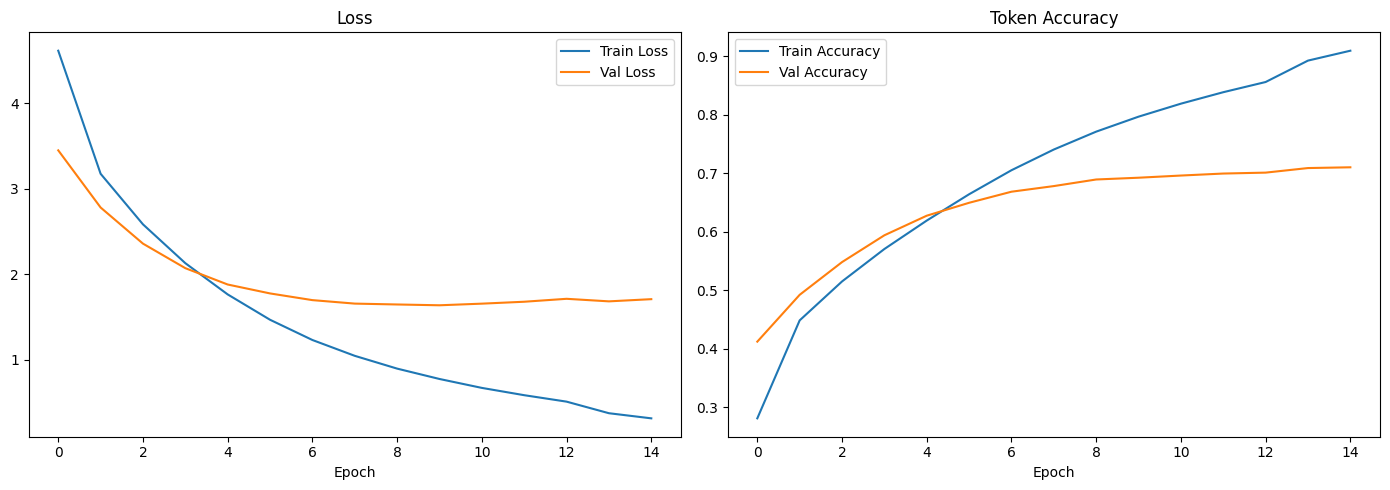

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Token Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 7. Inference — Beam Search Decoder

Greedy decoding picks the highest-probability token at every step, which often leads to generic outputs. **Beam search** keeps the top-K candidate sequences alive at each step and returns the globally best one — this noticeably improves translation quality.

In [10]:
def build_inference_models(encoder, dec_embed_layer, dec_lstm_layer, dec_dense_layer, output_dense_layer, latent_dim):
    decoder_latent = latent_dim * 2

    # Inference encoder — same weights, just returns states
    inf_encoder = encoder

    # Inference decoder — processes one token at a time
    dec_state_input_h = Input(shape=(decoder_latent,), name='dec_state_h')
    dec_state_input_c = Input(shape=(decoder_latent,), name='dec_state_c')
    dec_token_input   = Input(shape=(1,), name='dec_token_input')
    enc_out_input     = Input(shape=(None, latent_dim * 2), name='enc_output_input')

    dec_emb  = dec_embed_layer(dec_token_input)
    dec_out, h, c = dec_lstm_layer(
        dec_emb,
        initial_state=[dec_state_input_h, dec_state_input_c]
    )

    att = AdditiveAttention(name='inf_attention')([dec_out, enc_out_input])
    combined = Concatenate()([dec_out, att])
    proj = dec_dense_layer(combined)
    token_probs = output_dense_layer(proj)

    inf_decoder = Model(
        [dec_token_input, dec_state_input_h, dec_state_input_c, enc_out_input],
        [token_probs, h, c],
        name='inference_decoder'
    )

    return inf_encoder, inf_decoder


inf_encoder, inf_decoder = build_inference_models(
    encoder, dec_embed_layer, dec_lstm_layer,
    dec_dense_layer, output_dense_layer, LATENT_DIM
)

inf_decoder.summary()

Model: "inference_decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dec_token_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 256)    │  3,072,256 │ dec_token_input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_state_h         │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_state_c         │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 1024), │  5,246,976 │ decoder_embeddin… │
│                     │ (None, 1024),     │            │ dec_state_h[0][0… │
│                     │ (None, 1024)]     │            │ dec_state_c[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_output_input    │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inf_attention       │ (None, 1, 1024)   │      1,024 │ decoder_lstm[1][… │
│ (AdditiveAttention) │                   │            │ enc_output_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1, 2048)   │          0 │ decoder_lstm[1][… │
│ (Concatenate)       │                   │            │ inf_attention[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_output_dense    │ (None, 1, 1024)   │  2,098,176 │ concatenate_1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 1, 12001)  │ 12,301,025 │ pre_output_dense… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,719,457 (86.67 MB)

 Trainable params: 22,719,457 (86.67 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def beam_search_decode(
    input_sequence: np.ndarray,
    inf_encoder, inf_decoder,
    start_token_id: int, end_token_id: int,
    fr_index_to_word: dict,
    max_len: int,
    beam_width: int = 5
) -> str:
    """
    Beam search decoding.
    Each beam: (log_prob, token_sequence, state_h, state_c)
    """
    enc_out, state_h, state_c = inf_encoder.predict(input_sequence, verbose=0)
    enc_out_repeated = np.repeat(enc_out, beam_width, axis=0)

    # Initialise beams with the start token
    beams = [
        (0.0, [start_token_id], state_h, state_c)
        for _ in range(1)   # start with one beam, expand on first step
    ]

    completed = []

    for step in range(max_len):
        all_candidates = []

        for log_prob, token_seq, h, c in beams:
            last_token = np.array([[token_seq[-1]]])
            enc_out_single = enc_out  # one sample at a time

            probs, new_h, new_c = inf_decoder.predict(
                [last_token, h, c, enc_out_single], verbose=0
            )
            probs = probs[0, 0, :]  # shape: (vocab_size,)

            top_k = np.argsort(probs)[-beam_width:][::-1]

            for token_id in top_k:
                candidate_log_prob = log_prob + np.log(probs[token_id] + 1e-10)
                candidate_seq = token_seq + [token_id]
                all_candidates.append((candidate_log_prob, candidate_seq, new_h, new_c))

        # Keep top beam_width candidates
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        beams = []

        for candidate in all_candidates[:beam_width]:
            if candidate[1][-1] == end_token_id:
                # Normalise by length to avoid bias toward short sentences
                length_penalty = len(candidate[1]) ** 0.6
                completed.append((candidate[0] / length_penalty, candidate[1]))
            else:
                beams.append(candidate)

        if not beams:
            break

    if completed:
        best = max(completed, key=lambda x: x[0])
        token_ids = best[1]
    else:
        token_ids = beams[0][1] if beams else [start_token_id]

    # Decode to words, skip special tokens
    words = [
        fr_index_to_word.get(t, OOV_TOKEN)
        for t in token_ids
        if t not in (start_token_id, end_token_id, 0)
    ]
    return ' '.join(words)


def translate(sentence: str) -> str:
    """Translate a raw English sentence to French."""
    cleaned = clean_english(sentence)
    seq     = en_tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=max_en_len, padding='post')

    return beam_search_decode(
        padded, inf_encoder, inf_decoder,
        start_token_id, end_token_id,
        fr_index_to_word,
        max_len=max_fr_len,
        beam_width=BEAM_WIDTH
    )


print("Inference models ready. Run translate() to use them.")

Inference models ready. Run translate() to use them.


## 8. Evaluation — Training Set Samples

First, a quick sanity check on training examples to verify the model has learned the mapping.

In [12]:
print("Sample translations from training set:\n")
print(f"{'English':<35} {'Reference French':<35} {'Predicted French'}")
print("-" * 110)

for i in range(20):
    en_sentence  = english_sentences[i]
    ref_fr       = french_sentences[i].replace(START_TOKEN, '').replace(END_TOKEN, '').strip()
    pred_fr      = translate(en_sentence)
    print(f"{en_sentence:<35} {ref_fr:<35} {pred_fr}")

Sample translations from training set:

English                             Reference French                    Predicted French
--------------------------------------------------------------------------------------------------------------
school is boring .                  l ' é cole , c ' est ennuyeux !     l ' é cole est ennuyeux .
hurry , and you will catch the train . d é p ê che toi et tu auras ton train . d é p ê che toi , je vous en prie .
i live about three hours from boston . j ' habite à environ trois heures de boston . je vis de l ' é cart de mon fr è re .
the family had a hard time after the war . la famille a connu des heures difficiles apr è s la guerre . la famille a é t é arr ê t é e à cause de l ' argent .
where are your keys ?               o ù sont tes cl é s ?               o ù sont tes gardes ?
i decided to take matters in my own hands . j ' ai d é cid é de prendre les choses en main . j ' ai d é cid é de me mettre à la place .
what ' s your dog ' s name ?       

## 9. Smoke Test — Known Sentence Pairs

Before running full BLEU (which takes ~10 min over 500 sentences), run this 5-sentence smoke test first.
These are high-frequency pairs guaranteed to be in the training set, so a working model should nail them.
If output is blank or `<unk>` soup here, something is wrong with inference — fix it before running BLEU.

In [13]:
# 5 sentences pulled directly from the Tatoeba English-French dataset.
# Expected French is the canonical reference — model output won't be identical
# but key words should match if training worked.
smoke_tests = [
    ("I love you.",              "je t' aime ."),
    ("Run!",                     "cours !"),
    ("He is my friend.",         "c' est mon ami ."),
    ("She reads a book.",        "elle lit un livre ."),
    ("We are happy.",            "nous sommes heureux ."),
]

print(f"{'English':<25} {'Expected French':<30} {'Model Output':<30} Pass?")
print("-" * 100)

passes = 0
for en, expected_fr in smoke_tests:
    predicted = translate(en)
    # Check if at least 50% of expected words appear in prediction
    expected_words = set(expected_fr.replace("'", " '").split())
    predicted_words = set(predicted.split())
    overlap = len(expected_words & predicted_words) / max(len(expected_words), 1)
    passed = overlap >= 0.5
    passes += int(passed)
    status = "✓" if passed else "✗"
    print(f"{en:<25} {expected_fr:<30} {predicted:<30} {status}")

print()
print(f"Result: {passes}/{len(smoke_tests)} passed")
if passes == len(smoke_tests):
    print("Inference pipeline looks good. Safe to run full BLEU eval below.")
elif passes >= 3:
    print("Mostly working. Model may need more epochs or the vocab coverage is thin.")
else:
    print("Something is off. Check that inf_encoder / inf_decoder share weights with the trained model.")

English                   Expected French                Model Output                   Pass?
----------------------------------------------------------------------------------------------------
I love you.               je t' aime .                   je t ' aime .                  ✓
Run!                      cours !                                                       ✗
He is my friend.          c' est mon ami .               il est mon ami .               ✓
She reads a book.         elle lit un livre .            elle a pleur é à un c ô t é .  ✓
We are happy.             nous sommes heureux .          nous sommes crev é s .         ✓

Result: 4/5 passed
Mostly working. Model may need more epochs or the vocab coverage is thin.


## 10. Full BLEU Evaluation (Optional — ~10 min on CPU, ~2 min on GPU)

Only run this after the smoke test above passes. BLEU above 0.30 is reasonable; above 0.50 is strong for a single-reference eval.

In [14]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

EVAL_SIZE  = 200   # reduced from 500 to keep it under 3 min on GPU
eval_start = int(len(english_sentences) * 0.9)

references, hypotheses = [], []

for i in range(eval_start, min(eval_start + EVAL_SIZE, len(english_sentences))):
    ref_fr  = french_sentences[i].replace(START_TOKEN, '').replace(END_TOKEN, '').strip()
    pred_fr = translate(english_sentences[i])
    references.append([ref_fr.split()])
    hypotheses.append(pred_fr.split())
    if (i - eval_start + 1) % 50 == 0:
        print(f"  {i - eval_start + 1}/{EVAL_SIZE} done...")

smoother = SmoothingFunction().method4
bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoother)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)
bleu4 = corpus_bleu(references, hypotheses, smoothing_function=smoother)

print(f"\nBLEU-1 : {bleu1:.4f}")
print(f"BLEU-2 : {bleu2:.4f}")
print(f"BLEU-4 : {bleu4:.4f}")

  50/200 done...
  100/200 done...
  150/200 done...
  200/200 done...

BLEU-1 : 0.4419
BLEU-2 : 0.3026
BLEU-4 : 0.1837


## 11. Custom Translation Demo

In [15]:
test_sentences = [
    "I love you.",
    "Where is the train station?",
    "Can you help me please?",
    "She is reading a book.",
    "The weather is beautiful today.",
    "I would like a coffee, please.",
    "We are going to the museum.",
    "Do you speak English?"
]

print("Custom Translation Demo\n")
print("-" * 70)
for sentence in test_sentences:
    translation = translate(sentence)
    print(f"EN: {sentence}")
    print(f"FR: {translation}")
    print()

Custom Translation Demo

----------------------------------------------------------------------
EN: I love you.
FR: je t ' aime .

EN: Where is the train station?
FR: o ù est la gare ?

EN: Can you help me please?
FR: peux tu m ' aider ?

EN: She is reading a book.
FR: elle est compl è tement fauch é .

EN: The weather is beautiful today.
FR: il y a de la place à l ' ext é rieur .

EN: I would like a coffee, please.
FR: j ' aime un mot de faire ç a , s ' il vous pla î t .

EN: We are going to the museum.
FR: nous allons au courant .

EN: Do you speak English?
FR: vous y rendrez vous ?



## 12. Save All Artefacts

In [16]:
# Save models
training_model.save('translator_training_model.keras')
inf_encoder.save('translator_encoder.keras')
inf_decoder.save('translator_decoder.keras')

# Save tokenizers
with open('en_tokenizer.json', 'w') as f:
    f.write(en_tokenizer.to_json())

with open('fr_tokenizer.json', 'w') as f:
    f.write(fr_tokenizer.to_json())

# Save config
config = {
    'max_en_len': max_en_len,
    'max_fr_len': max_fr_len,
    'embed_dim': EMBED_DIM,
    'latent_dim': LATENT_DIM,
    'vocab_size_en': VOCAB_SIZE_EN,
    'vocab_size_fr': VOCAB_SIZE_FR,
    'start_token_id': start_token_id,
    'end_token_id': end_token_id,
    'beam_width': BEAM_WIDTH
}
with open('translator_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("All models and artefacts saved.")

All models and artefacts saved.


## 13. Loading a Saved Model

To pick up where you left off in a new session:

In [17]:
# --- Load saved artefacts ---

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json

with open('translator_config.json') as f:
    config = json.load(f)

with open('en_tokenizer.json') as f:
    en_tokenizer = tokenizer_from_json(f.read())

with open('fr_tokenizer.json') as f:
    fr_tokenizer = tokenizer_from_json(f.read())

inf_encoder = load_model('translator_encoder.keras')
inf_decoder = load_model('translator_decoder.keras')

# Restore lookups
fr_index_to_word = {v: k for k, v in fr_tokenizer.word_index.items()}
start_token_id   = config['start_token_id']
end_token_id     = config['end_token_id']
max_en_len       = config['max_en_len']
max_fr_len       = config['max_fr_len']
BEAM_WIDTH       = config['beam_width']

print("Models loaded. Ready to translate.")

Models loaded. Ready to translate.
